<a href="https://colab.research.google.com/github/Raviteja0707200/Customer-Churn-Analytics-Segmentation-Retention-Prediction-System/blob/main/Customer_Churn_Analytics%2C_Segmentation_%26_Retention_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month              Yes   
1          No             

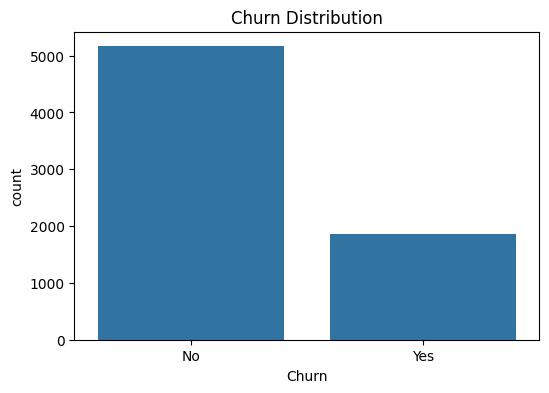

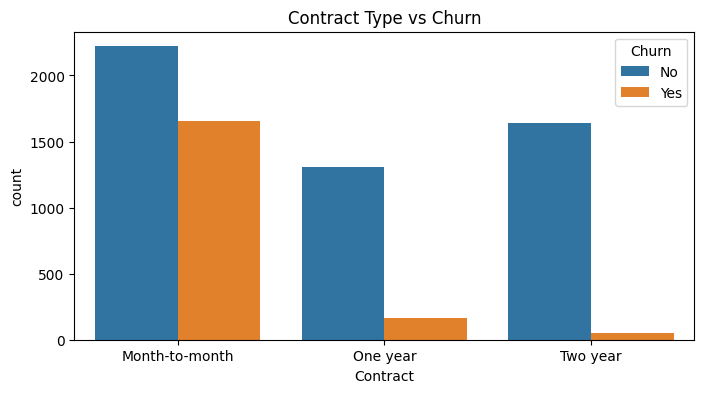

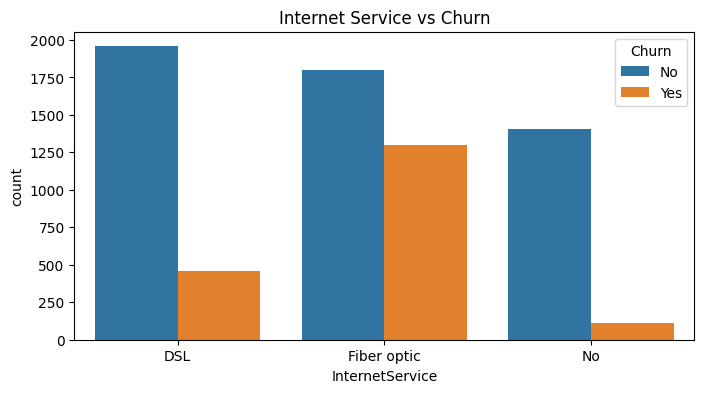

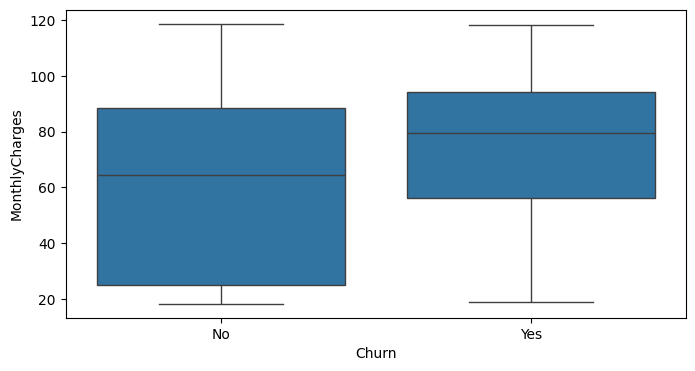

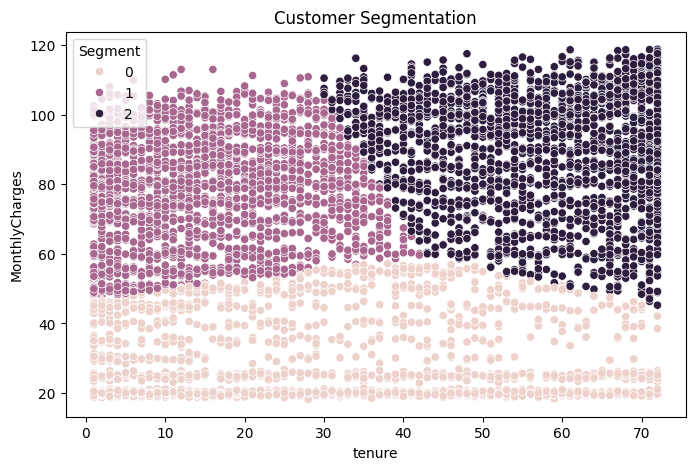

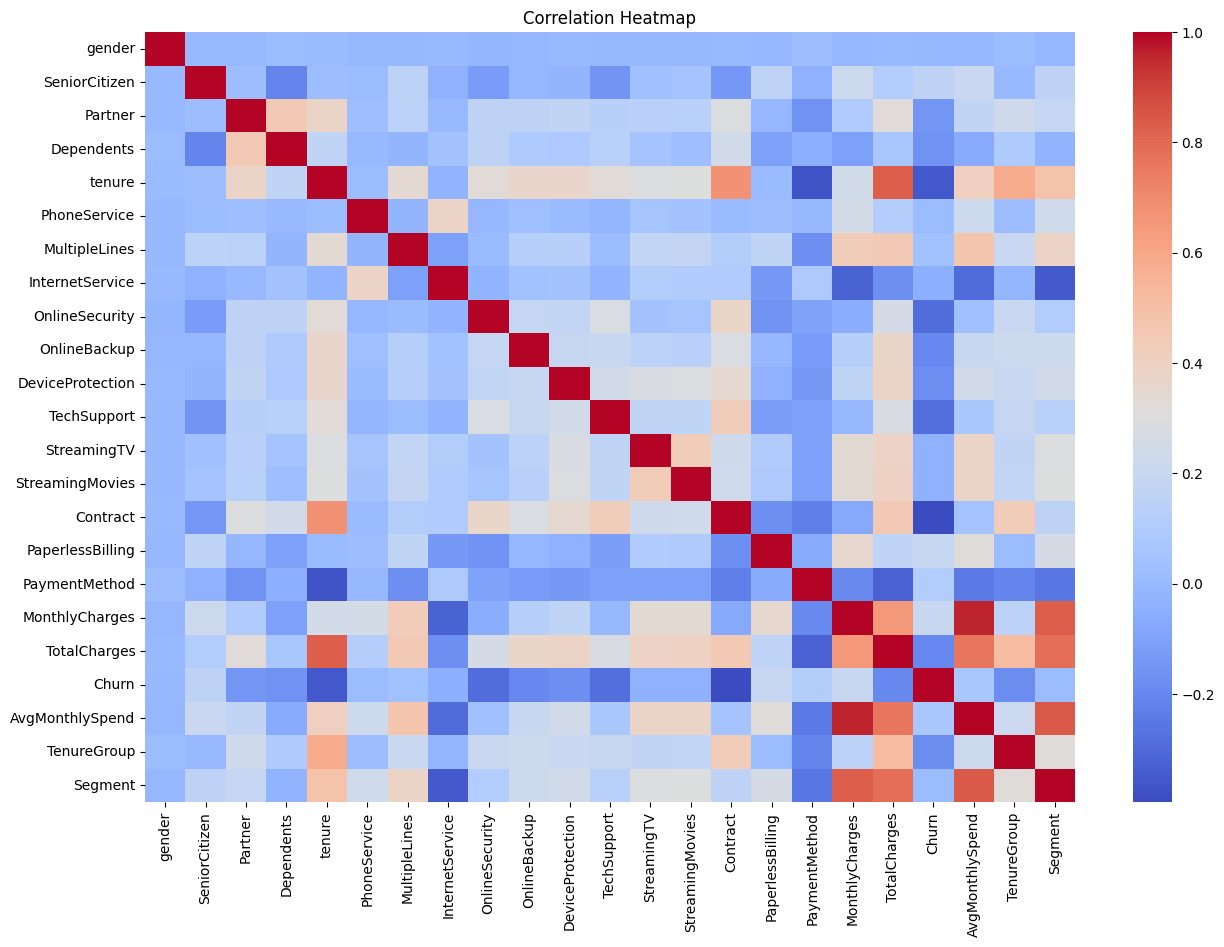

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy
0  Logistic Regression  0.788202
1        Decision Tree  0.722814
2        Random Forest  0.789623

Best Model Accuracy: 73.21
ROC AUC: 0.8352
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407



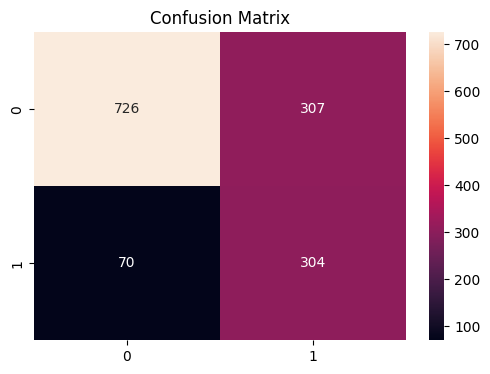

             Feature  Importance
14          Contract    0.255832
4             tenure    0.118711
8     OnlineSecurity    0.106639
11       TechSupport    0.091714
17    MonthlyCharges    0.066529
18      TotalCharges    0.064684
7    InternetService    0.063660
20       TenureGroup    0.061196
19   AvgMonthlySpend    0.042171
9       OnlineBackup    0.032567
21           Segment    0.020797
10  DeviceProtection    0.018443
16     PaymentMethod    0.018310
15  PaperlessBilling    0.010388
3         Dependents    0.005285


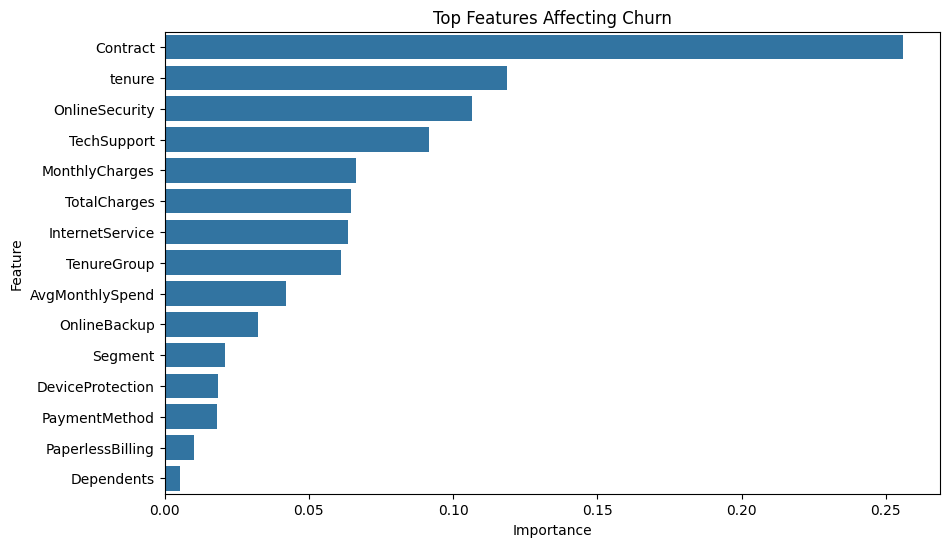


Top 20 High-Risk Customers
      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
4585       0              1        0           0       1             1   
2464       0              0        0           0       1             1   
3380       1              1        1           0       1             1   
6633       0              0        0           0       1             1   
6240       1              0        0           1       1             1   
2510       1              0        0           0       1             1   
2397       1              0        0           0       1             1   
642        1              0        0           0       1             1   
1731       0              1        0           0       1             1   
2607       1              1        0           0       1             1   
2888       0              1        0           1       1             1   
3328       0              0        0           0       1             1   
5662      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.dropna(inplace=True)

df['AvgMonthlySpend'] = (
    df['TotalCharges'] /
    (df['tenure'] + 1)
)

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        'New',
        'Regular',
        'Loyal',
        'Very Loyal'
    ]
)

print(df.head())

plt.figure(figsize=(6,4))
sns.countplot(
    x='Churn',
    data=df
)
plt.title('Churn Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)
plt.title('Contract Type vs Churn')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.title('Internet Service vs Churn')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.show()

segment_data = df[
    ['MonthlyCharges','tenure']
].copy()

segment_data.columns = [
    'MonthlyCharges',
    'tenure'
]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Segment'] = kmeans.fit_predict(
    segment_data
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Segment',
    data=df
)

plt.title('Customer Segmentation')
plt.show()

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

    if str(df[col].dtype) == 'category':
        df[col] = encoder.fit_transform(df[col])

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

models = {
    'Logistic Regression':
        LogisticRegression(max_iter=1000),

    'Decision Tree':
        DecisionTreeClassifier(random_state=42),

    'Random Forest':
        RandomForestClassifier(
            random_state=42
        )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [name, acc]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy'
    ]
)

print(results_df)

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(
    X_train,
    y_train
)

best_model = grid.best_estimator_

pred = best_model.predict(
    X_test
)

prob = best_model.predict_proba(
    X_test
)[:,1]

accuracy = accuracy_score(
    y_test,
    pred
)

auc = roc_auc_score(
    y_test,
    prob
)

print("\nBest Model Accuracy:",
      round(accuracy*100,2))

print("ROC AUC:",
      round(auc,4))

print(
    classification_report(
        y_test,
        pred
    )
)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

importance = pd.DataFrame({
    'Feature':
        X.columns,
    'Importance':
        best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title(
    'Top Features Affecting Churn'
)

plt.show()

risk_customers = X_test.copy()

risk_customers[
    'RiskScore'
] = prob

risk_customers = risk_customers.sort_values(
    by='RiskScore',
    ascending=False
)

print(
    "\nTop 20 High-Risk Customers"
)

print(
    risk_customers.head(20)
)

print("\nBusiness Insights")
print("- Month-to-month contracts show highest churn.")
print("- Customers with short tenure are more likely to leave.")
print("- High monthly charges increase churn risk.")
print("- Customer segmentation identified loyal and at-risk groups.")
print("- Retention campaigns should target high-risk customers.")